# REINFORCE Algorithm in Gridworld
This notebook demonstrates the REINFORCE algorithm, a Monte Carlo policy gradient method, applied to a simple Gridworld environment. Each section is explained in detail below.

**What is REINFORCE?**

REINFORCE is a foundational policy gradient algorithm in reinforcement learning. It updates the policy parameters in the direction that increases the expected return, using sampled trajectories and their returns. In this notebook, you will see how REINFORCE is implemented for a discrete Gridworld, how the policy is updated, and how the agent's performance evolves over time.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.special import softmax

## Environment and Parameters Setup
We define the reward structure for each state in the 4x4 grid, set the terminal state, initialize the policy parameters, learning rate (alpha), and a log for scores.

In [2]:
rewards = np.zeros(16)
rewards[3] = 10
rewards[2] = -1
rewards[11] = -1
rewards[10] = -1

terminal_state = 3
state_action_logprobs = np.random.random((16,4))
alpha = 0.005

score_log = []

## Visualizing the Reward Structure
This cell visualizes the reward values for each state in the 4x4 grid. High and low reward states are easily identified in the plot.

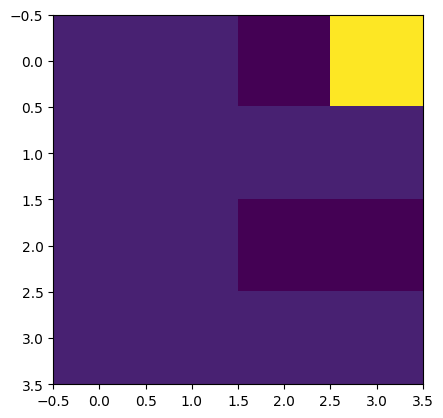

In [3]:
plt.imshow(rewards.reshape(4, 4))

## Loading the State Transition Table
We load the state transition table from a CSV file. This table defines how the agent moves between states given an action.

In [4]:
state_transition_table = np.genfromtxt("state_transitions.csv", delimiter=",").astype(int)

## Calculating Returns
This function computes the return (discounted sum of rewards) for each time step in an episode, which is used to update the policy.

In [5]:
def returns_calc(rewards):
    returns = []
    R = 0
    gamma = 0.9
    for i in reversed(range(len(rewards))):
        R = rewards[i] + gamma * R
        returns.insert(0, R)
    return returns

## Agent Evaluation Function
This function simulates the agent's behavior using the current policy to select actions, and returns the total reward and the sequence of visited states.

In [6]:
def test_agent():
    state = 12
    done = False
    steps = 0
    total_rewards = 0
    states_log = []
    while (not(state == terminal_state)) and steps<30:
        states_log.append(state)
        action = np.argmax(np.random.multinomial(1, softmax(state_action_logprobs[state]), size=1))
        state = state_transition_table[state, action]
        total_rewards += rewards[state]
        steps += 1
    states_log.append(state)
    return total_rewards, states_log

## REINFORCE: Main Training Loop
This loop runs multiple episodes where the agent explores the environment, collects rewards, and updates the policy parameters using the REINFORCE algorithm. The agent's performance is logged for analysis.

In [7]:
for _ in range(1000):
    state = 12
    state_log = []
    reward_log = []
    action_log = []
    values_log = []

    steps = 0

    while (not(state == terminal_state)) and steps<30:
        action = np.argmax(np.random.multinomial(1, softmax(state_action_logprobs[state]), size=1))
        
        state_log.append(state)
        action_log.append(action)

        state = state_transition_table[state, action]
        reward_log.append(rewards[state])

        steps += 1
            
    state_returns = returns_calc(reward_log)
    advantage = np.array(state_returns)
    
    state_action_logprobs[state_log, action_log] = state_action_logprobs[state_log, action_log] + alpha*advantage
    
    score_log.append(test_agent()[0])

In [11]:
state_returns

[np.float64(5.9049000000000005),
 np.float64(6.561),
 np.float64(7.29),
 np.float64(8.1),
 np.float64(9.0),
 np.float64(10.0)]

## Visualizing the Learned Policy
This cell displays the learned action probabilities for each state after training, helping you see which actions the agent prefers in each state.

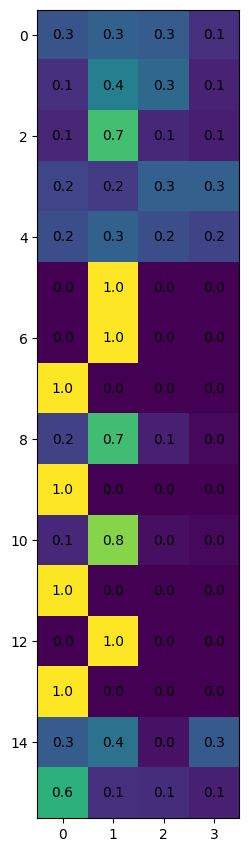

In [8]:
fig, ax1 = plt.subplots(1)
fig.set_size_inches(18.5, 10.5)
ax1.imshow(softmax(state_action_logprobs, 1).reshape(16, 4))

for (j,i), label in np.ndenumerate(softmax(state_action_logprobs, 1).reshape(16, 4).round(1)):
    ax1.text(i,j,label,ha='center',va='center')

## Plotting the Learning Curve
This cell plots the agent's score over time, showing how the agent's performance improves as it learns.

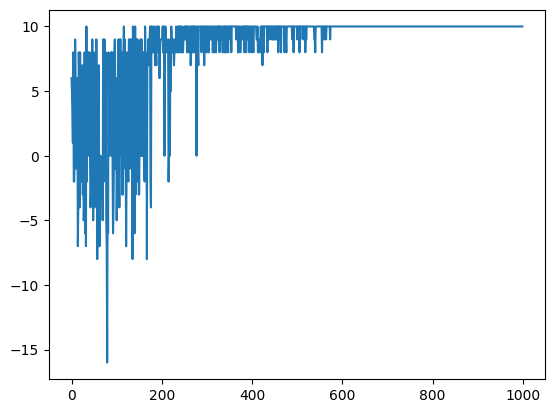

In [9]:
plt.plot(score_log)

## Visualizing the Agent's Path
This cell shows the path taken by the agent from the start state to the terminal state using the learned policy.

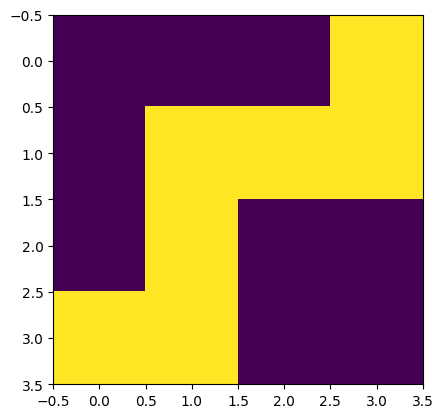

In [10]:
_, state_log = test_agent()
state_view = np.zeros(16)
state_view[state_log] = 1
plt.imshow(state_view.reshape(4,4))